<a href="https://colab.research.google.com/github/rifahnanjiba02-arch/remoteclip-ucm/blob/main/01_remote_clip_linear_probe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear probing using RemoteCLIP as a frozen feature extractor

In [1]:
from datasets import load_dataset

ds = load_dataset("rifahnanjiba2/UC_Merced")

README.md:   0%|          | 0.00/2.95k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  416MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/2100 [00:00<?, ? examples/s]

In [4]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU not available")


CUDA available: True
GPU: Tesla T4


In [3]:
!pip install -q open-clip-torch huggingface_hub


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.5 MB/s eta 0:00:00


In [5]:
from huggingface_hub import hf_hub_download

checkpoint_path = hf_hub_download(
    repo_id="chendelong/RemoteCLIP",
    filename="RemoteCLIP-ViT-B-32.pt"
)

print("Checkpoint:", checkpoint_path)


RemoteCLIP-ViT-B-32.pt: reconstructing file:   0%|          |  0.00B /  605MB            

RemoteCLIP-ViT-B-32.pt: downloading bytes:           |  0.00B            

Checkpoint: /root/.cache/huggingface/hub/models--chendelong--RemoteCLIP/snapshots/bf1d8a3ccf2ddbf7c875705e46373bfe542bce38/RemoteCLIP-ViT-B-32.pt


In [6]:
import torch
import open_clip

device = torch.device("cuda")

model, _, preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32",
    pretrained=None
)

checkpoint = torch.load(
    checkpoint_path,
    map_location="cpu"
)

model.load_state_dict(checkpoint)

model = model.to(device)
model.eval()

print("Model device:", next(model.parameters()).device)


Model device: cuda:0


# Split the dataset

In [7]:
print(ds)
print(ds["train"].features)
print(ds["train"][0])


DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 2100
    })
})
{'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['agricultural', 'airplane', 'baseballdiamond', 'beach', 'buildings', 'chaparral', 'denseresidential', 'forest', 'freeway', 'golfcourse', 'harbor', 'intersection', 'mediumresidential', 'mobilehomepark', 'overpass', 'parkinglot', 'river', 'runway', 'sparseresidential', 'storagetanks', 'tenniscourt'])}
{'image': <PIL.TiffImagePlugin.TiffImageFile image mode=RGB size=256x256 at 0x78435AD7E510>, 'label': 0}


In [8]:
from datasets import DatasetDict

# original dataset
data = ds["train"]

# 70% train, 30% temporary
split_1 = data.train_test_split(
    test_size=0.30,
    seed=42,
    stratify_by_column="label"
)

# Split the 30% into 15% validation and 15% test
split_2 = split_1["test"].train_test_split(
    test_size=0.50,
    seed=42,
    stratify_by_column="label"
)

# final dataset
ds = DatasetDict({
    "train": split_1["train"],
    "validation": split_2["train"],
    "test": split_2["test"]
})

print(ds)


DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 1470
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 315
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 315
    })
})


In [9]:
import torch

# Get one image
image = ds["train"][0]["image"]

# Preprocess the image
image_tensor = preprocess(image).unsqueeze(0).to(device)

print("Image shape:", image_tensor.shape)
print("Image device:", image_tensor.device)


Image shape: torch.Size([1, 3, 224, 224])
Image device: cuda:0


In [10]:
with torch.no_grad():
    image_features = model.encode_image(image_tensor)

print("Feature shape:", image_features.shape)
print("Feature device:", image_features.device)


Feature shape: torch.Size([1, 512])
Feature device: cuda:0


# Extract RemoteCLIP features

In [13]:
from torch.utils.data import DataLoader
import torch

model.eval()

def extract_features(dataset, batch_size=32):

    def collate_fn(batch):
        images = [item["image"] for item in batch]
        labels = torch.tensor([item["label"] for item in batch])
        return images, labels

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn
    )

    all_features = []
    all_labels = []

    for images, labels in loader:

        # Apply RemoteCLIP preprocessing to each PIL image
        images = torch.stack([
            preprocess(image) for image in images
        ]).to(device)

        with torch.no_grad():
            features = model.encode_image(images)

        # Normalize RemoteCLIP features
        features = features / features.norm(
            dim=-1,
            keepdim=True
        )

        all_features.append(features.cpu())
        all_labels.append(labels)

    features = torch.cat(all_features)
    labels = torch.cat(all_labels)

    return features, labels


In [14]:
train_features, train_labels = extract_features(
    ds["train"],
    batch_size=32
)

print("Train features:", train_features.shape)
print("Train labels:", train_labels.shape)


Train features: torch.Size([1470, 512])
Train labels: torch.Size([1470])


In [15]:
val_features, val_labels = extract_features(
    ds["validation"],
    batch_size=32
)

print("Validation features:", val_features.shape)
print("Validation labels:", val_labels.shape)


Validation features: torch.Size([315, 512])
Validation labels: torch.Size([315])


In [16]:
test_features, test_labels = extract_features(
    ds["test"],
    batch_size=32
)

print("Test features:", test_features.shape)
print("Test labels:", test_labels.shape)


Test features: torch.Size([315, 512])
Test labels: torch.Size([315])


# Create the classifier

In [17]:
import torch
import torch.nn as nn

num_classes = ds["train"].features["label"].num_classes
feature_dim = train_features.shape[1]

classifier = nn.Linear(feature_dim, num_classes).to(device)

print("Feature dimension:", feature_dim)
print("Number of classes:", num_classes)
print("Classifier:", classifier)


Feature dimension: 512
Number of classes: 21
Classifier: Linear(in_features=512, out_features=21, bias=True)


# Create DataLoaders

In [18]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(train_features, train_labels)
val_dataset = TensorDataset(val_features, val_labels)
test_dataset = TensorDataset(test_features, test_labels)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))


Train batches: 46
Validation batches: 10
Test batches: 10


In [19]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    classifier.parameters(),
    lr=1e-3
)

num_epochs = 20


In [20]:
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):

    # Training
    classifier.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for features, labels in train_loader:

        features = features.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = classifier(features)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * features.size(0)

        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_accuracy = correct / total


    # Validation
    classifier.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for features, labels in val_loader:

            features = features.to(device)
            labels = labels.to(device)

            outputs = classifier(features)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * features.size(0)

            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    val_loss = running_loss / total
    val_accuracy = correct / total

    # Save metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )


Epoch [1/20] Train Loss: 2.9249 | Train Acc: 0.6027 | Val Loss: 2.7904 | Val Acc: 0.9175
Epoch [2/20] Train Loss: 2.6744 | Train Acc: 0.9558 | Val Loss: 2.5485 | Val Acc: 0.9778
Epoch [3/20] Train Loss: 2.4393 | Train Acc: 0.9626 | Val Loss: 2.3201 | Val Acc: 0.9746
Epoch [4/20] Train Loss: 2.2187 | Train Acc: 0.9694 | Val Loss: 2.1082 | Val Acc: 0.9746
Epoch [5/20] Train Loss: 2.0127 | Train Acc: 0.9816 | Val Loss: 1.9104 | Val Acc: 0.9778
Epoch [6/20] Train Loss: 1.8227 | Train Acc: 0.9844 | Val Loss: 1.7299 | Val Acc: 0.9714
Epoch [7/20] Train Loss: 1.6486 | Train Acc: 0.9850 | Val Loss: 1.5647 | Val Acc: 0.9778
Epoch [8/20] Train Loss: 1.4910 | Train Acc: 0.9864 | Val Loss: 1.4160 | Val Acc: 0.9746
Epoch [9/20] Train Loss: 1.3502 | Train Acc: 0.9864 | Val Loss: 1.2834 | Val Acc: 0.9810
Epoch [10/20] Train Loss: 1.2243 | Train Acc: 0.9857 | Val Loss: 1.1654 | Val Acc: 0.9810
Epoch [11/20] Train Loss: 1.1130 | Train Acc: 0.9864 | Val Loss: 1.0614 | Val Acc: 0.9810
Epoch [12/20] Train

# Plot Loss & Accuracy

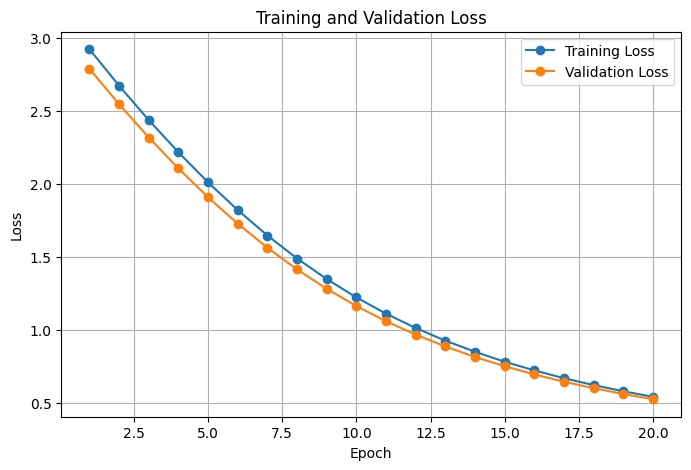

In [21]:
import matplotlib.pyplot as plt

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_losses,
    label="Training Loss",
    marker="o"
)

plt.plot(
    epochs,
    val_losses,
    label="Validation Loss",
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


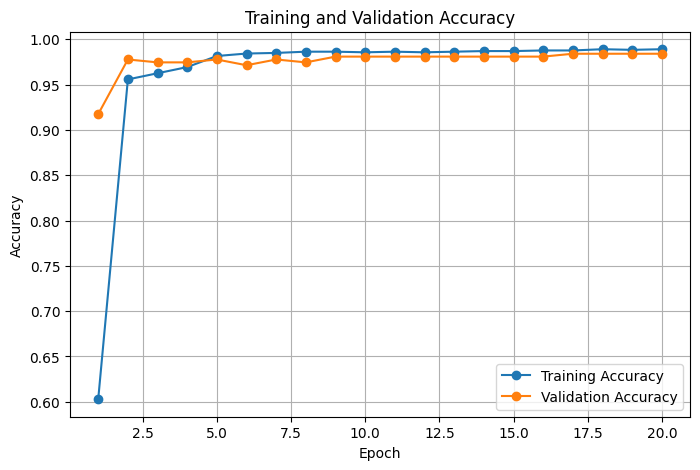

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_accuracies,
    label="Training Accuracy",
    marker="o"
)

plt.plot(
    epochs,
    val_accuracies,
    label="Validation Accuracy",
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


# Evaluation on Test Set

In [23]:
classifier.eval()

correct = 0
total = 0

all_predictions = []
all_true_labels = []

with torch.no_grad():

    for features, labels in test_loader:

        features = features.to(device)
        labels = labels.to(device)

        outputs = classifier(features)
        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

        all_predictions.extend(predictions.cpu().numpy())
        all_true_labels.extend(labels.cpu().numpy())

test_accuracy = correct / total

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


Test Accuracy: 0.9905
Test Accuracy: 99.05%
